# Transformación y tratamiento de variables

## Transformación de variables
En el análisis de datos, la transformación de variables es una técnica utilizada para modificar la escala o distribución de los datos con el fin de mejorar la interpretación, visualización o modelado.


### Importacion de librerías

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler

### Cargue de datos

In [2]:
df_raw = pd.read_csv('../../data/raw/DATOS_PROCESADOS.csv')
df_raw.head()

,FECHA_HORA_REPORTE,aerodromo,fecha_zulu,viento,visibilidad,nubosidad,temperatura/rocio,presion,fenomenos,direccion_viento,velocidad_viento
0,2006-07-20 00:00:00,SKBQ,200000Z,03009KT,9999,"FEW015CB, SCT080",28/24,A2983,"TS, CB, TS",30.0,9.0
1,2006-07-20 01:00:00,SKBQ,200100Z,25008KT,9999,"FEW015CB, SCT080",27/23,A2985,TS,250.0,8.0
2,2006-07-20 05:00:00,SKBO,200500Z,VRB02KT,9999,"FEW017, SCT200",09/09,A3036,NaN,NaN,2.0
3,2006-07-20 06:00:00,SKBQ,200600Z,29006KT,9999,"FEW015, SCT080",26/23,A2985,NaN,290.0,6.0
4,2006-07-20 07:00:00,SKBQ,200700Z,32006KT,9999,SCT012,26/24,A2984,NaN,320.0,6.0


### Conversion de variables

In [25]:
def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])
    
    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)
    
    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)
        
        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)
        
        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0
        
        return pd.Series([direccion, velocidad, rafaga])
    
    return pd.Series([None, None, None])

In [26]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df = df_raw.copy()
df['FECHA_HORA_REPORTE'] = pd.to_datetime(df_raw['FECHA_HORA_REPORTE'])
df.set_index('FECHA_HORA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df = df[['viento']]

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df = df[df['viento'].notna()]

# Modificar el valor KKT por KT en la columna de viento
df['viento'] = df['viento'].str.replace('KKT', 'KT', regex=False)

# Aplicación Regex para parsear la columna de viento con formato flexible
df[['direccion', 'intensidad_kt', 'rafaga_kt']] = df['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df['direccion'] = df['direccion'].ffill()

# Eliminacion de errores de digitación en la columna de viento, donde la longitud es mayor a 9 caracteres y la intensidad es NaN despues del parseo
df_2 = df[df['viento'].str.len() > 9]
df_2 = df_2[df_2["intensidad_kt"].isna()]
df = df.drop(df_2.index)

In [5]:
df.head()

,viento,direccion,intensidad_kt,rafaga_kt
FECHA_HORA_REPORTE,,,,
2006-07-20 00:00:00,03009KT,30.0,9.0,0.0
2006-07-20 01:00:00,25008KT,250.0,8.0,0.0
2006-07-20 05:00:00,VRB02KT,250.0,2.0,0.0
2006-07-20 06:00:00,29006KT,290.0,6.0,0.0
2006-07-20 07:00:00,32006KT,320.0,6.0,0.0


In [29]:
# Asegúrate de que el índice sea datetime
df.index = pd.to_datetime(df.index)

# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df.index.min().floor('H'), 
                              end=df.index.max().ceil('H'), 
                              freq='1H')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df[df.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 15063
Reportes extra encontrados: 9868


/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/3125760702.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_teorico = pd.date_range(start=df.index.min().floor('H'),
/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/3125760702.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=df.index.max().ceil('H'),


In [31]:
df.head(5)

,viento,direccion,intensidad_kt,rafaga_kt
FECHA_HORA_REPORTE,,,,
2006-07-20 00:00:00,03009KT,30.0,9.0,0.0
2006-07-20 01:00:00,25008KT,250.0,8.0,0.0
2006-07-20 05:00:00,VRB02KT,250.0,2.0,0.0
2006-07-20 06:00:00,29006KT,290.0,6.0,0.0
2006-07-20 07:00:00,32006KT,320.0,6.0,0.0


In [32]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE
# u = componente Este-Oeste, v = componente Norte-Sur
from tkinter.messagebox import IGNORE


radianes = df['direccion'] * (np.pi / 180)
df['u'] = -df['intensidad_kt'] * np.sin(radianes) 
df['v'] = -df['intensidad_kt'] * np.cos(radianes)

# 2. Definir reglas de agregación para tus columnas
reglas = {
    'u': 'mean',          # Promedio de la componente zonal
    'v': 'mean',          # Promedio de la componente meridional
    'intensidad_kt': 'mean', 
    'rafaga_kt': 'max'    # Capturamos la ráfaga más fuerte de la hora
}

# 3. Forzar la frecuencia horaria (Resample)
# Esto agrupa los METAR y SPECI que mencionaste
df_modelo = df.resample('1H').agg(reglas)
df = df.resample('1H').agg(reglas) # Para validar que el resample funciona correctamente, lo dejo en df también

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia [cite: 68, 129]
df_modelo['u'] = df_modelo['u'].interpolate(method='linear')
df_modelo['v'] = df_modelo['v'].interpolate(method='linear')
df_modelo['intensidad_kt'] = df_modelo['intensidad_kt'].interpolate(method='linear')
df_modelo['rafaga_kt'] = df_modelo['rafaga_kt'].fillna(0) # Si no hay reporte, rafaga es 0

/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/1044056073.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df.resample('1H').agg(reglas)
/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/1044056073.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').agg(reglas) # Para validar que el resample funciona correctamente, lo dejo en df también


In [33]:
# Asegúrate de que el índice sea datetime
df_modelo.index = pd.to_datetime(df_modelo.index)

# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_modelo.index.min().floor('H'), 
                              end=df_modelo.index.max().ceil('H'), 
                              freq='1H')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_modelo.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_modelo[df_modelo.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 0
Reportes extra encontrados: 0


/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/2542275217.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_teorico = pd.date_range(start=df_modelo.index.min().floor('H'),
/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/2542275217.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=df_modelo.index.max().ceil('H'),


/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/1825780985.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1H')


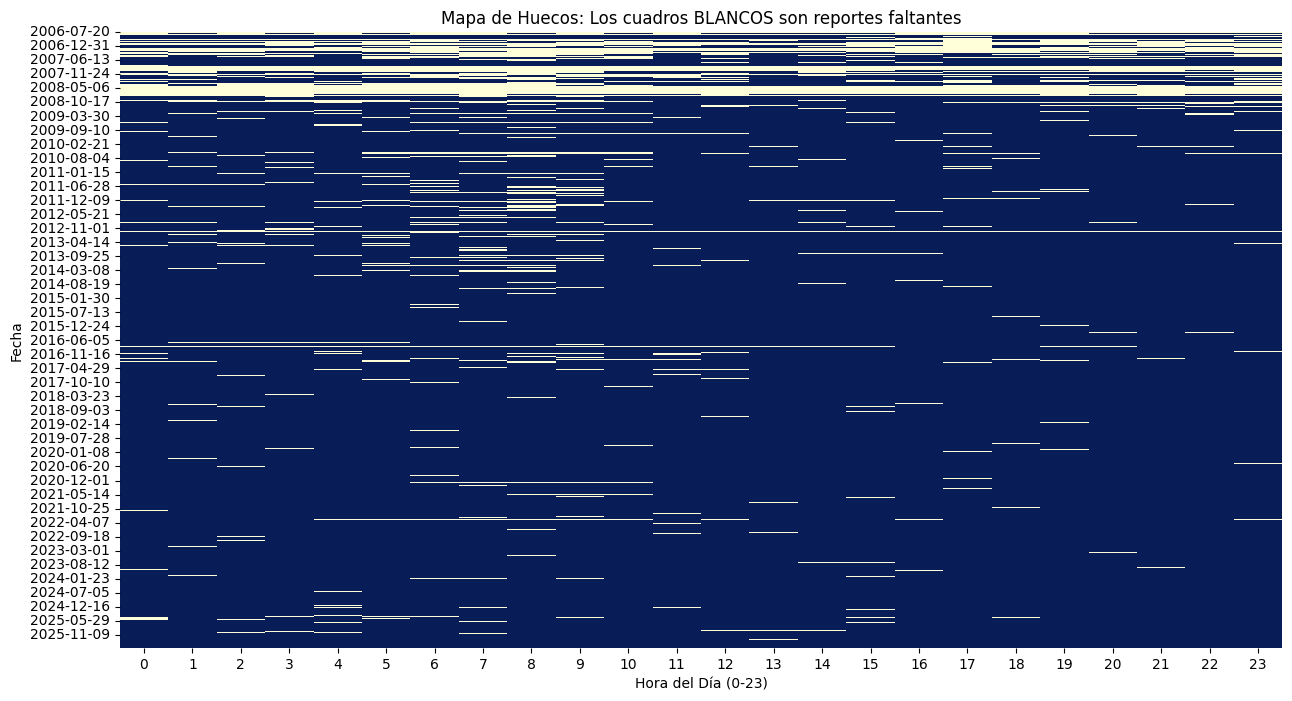

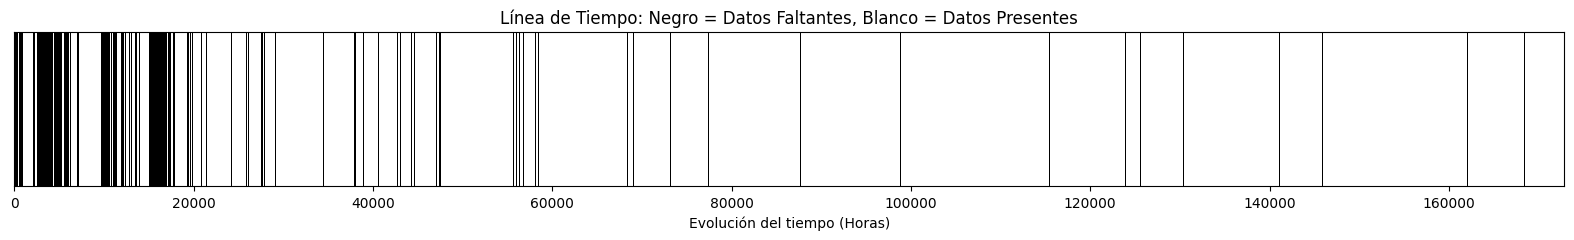

In [35]:
# 1. Asegúrate de tener un índice de tiempo completo (reindex)
# Esto crea filas con 'NaN' donde no había reporte
rango_completo = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1H')
df_visual = df.reindex(rango_completo)

# --- GRÁFICO 1: MAPA DE CALOR POR HORA ---
# Preparamos los datos: una fila por día, una columna por hora
df_visual['fecha'] = df_visual.index.date
df_visual['hora'] = df_visual.index.hour

# Usamos la columna 'intensidad_kt' para ver si hay dato (True) o no (False)
pivot_df = df_visual.pivot(index='fecha', columns='hora', values='intensidad_kt')

plt.figure(figsize=(15, 8))
# sns.heatmap mostrará en blanco (NaN) donde falten datos
sns.heatmap(pivot_df.isna(), cmap='YlGnBu_r', cbar=False)
plt.title('Mapa de Huecos: Los cuadros BLANCOS son reportes faltantes')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Fecha')
plt.show()

# --- GRÁFICO 2: CÓDIGO DE BARRAS TEMPORAL ---
plt.figure(figsize=(20, 2))
plt.imshow(df_visual['intensidad_kt'].isna().values.reshape(1, -1), 
           cmap='binary', aspect='auto', interpolation='nearest')
plt.title('Línea de Tiempo: Negro = Datos Faltantes, Blanco = Datos Presentes')
plt.yticks([])
plt.xlabel('Evolución del tiempo (Horas)')
plt.show()

/var/folders/1d/4xpyp95n6z95ghx142cshf000000gn/T/ipykernel_9562/311813219.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_completo = pd.date_range(start=df_modelo.index.min(), end=df_modelo.index.max(), freq='1H')


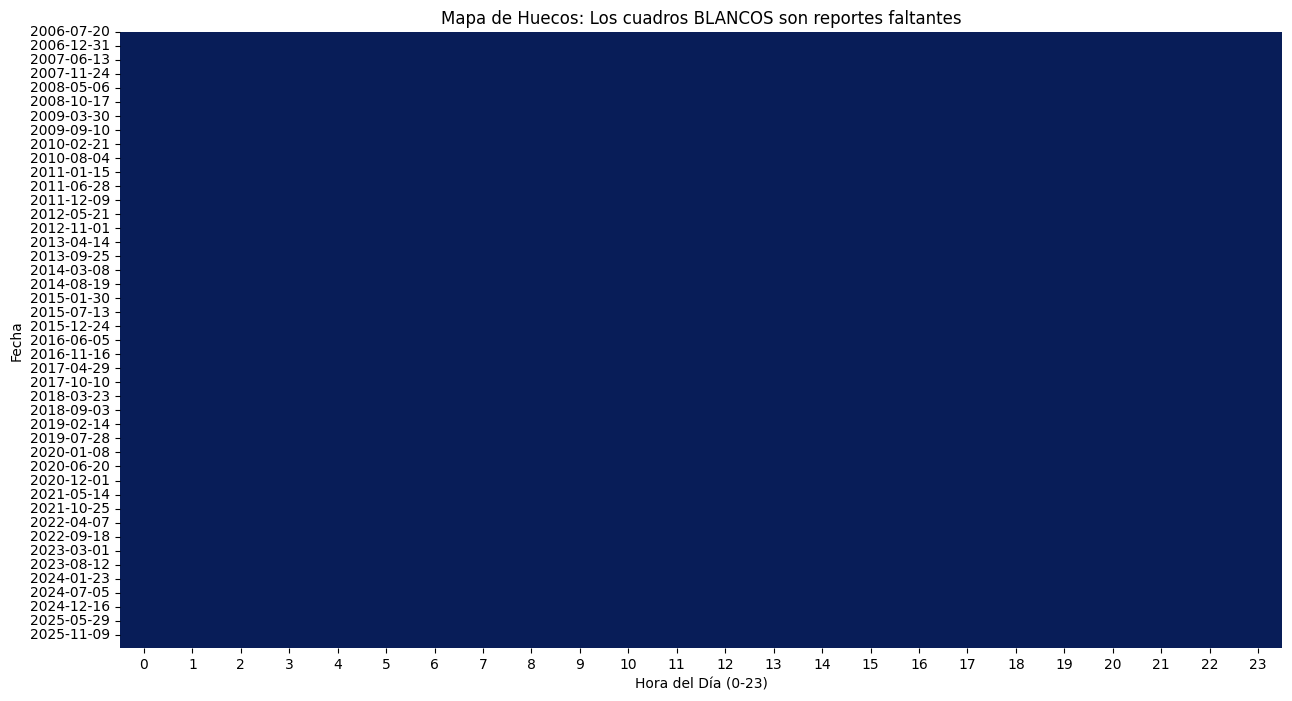

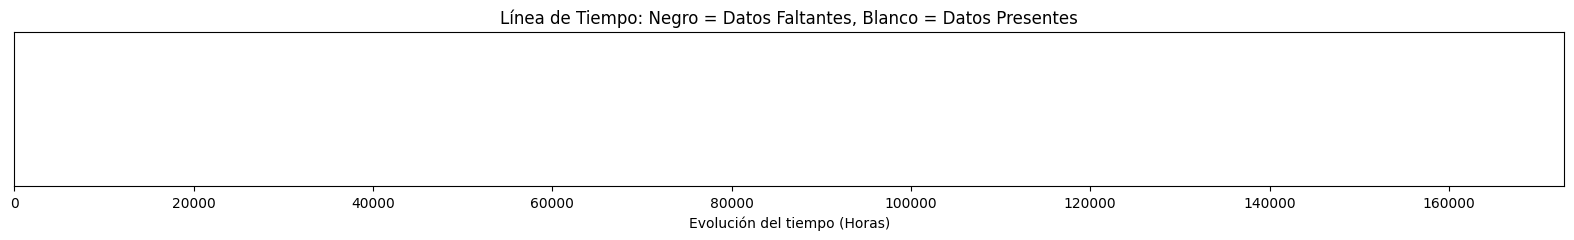

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegúrate de tener un índice de tiempo completo (reindex)
# Esto crea filas con 'NaN' donde no había reporte
rango_completo = pd.date_range(start=df_modelo.index.min(), end=df_modelo.index.max(), freq='1H')
df_visual = df_modelo.reindex(rango_completo)

# --- GRÁFICO 1: MAPA DE CALOR POR HORA ---
# Preparamos los datos: una fila por día, una columna por hora
df_visual['fecha'] = df_visual.index.date
df_visual['hora'] = df_visual.index.hour

# Usamos la columna 'intensidad_kt' para ver si hay dato (True) o no (False)
pivot_df = df_visual.pivot(index='fecha', columns='hora', values='intensidad_kt')

plt.figure(figsize=(15, 8))
# sns.heatmap mostrará en blanco (NaN) donde falten datos
sns.heatmap(pivot_df.isna(), cmap='YlGnBu_r', cbar=False)
plt.title('Mapa de Huecos: Los cuadros BLANCOS son reportes faltantes')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Fecha')
plt.show()

# --- GRÁFICO 2: CÓDIGO DE BARRAS TEMPORAL ---
plt.figure(figsize=(20, 2))
plt.imshow(df_visual['intensidad_kt'].isna().values.reshape(1, -1), 
           cmap='binary', aspect='auto', interpolation='nearest')
plt.title('Línea de Tiempo: Negro = Datos Faltantes, Blanco = Datos Presentes')
plt.yticks([])
plt.xlabel('Evolución del tiempo (Horas)')
plt.show()